# HW12: Time Series Forecasting with GRU
### temporal split, lag features, baselines, GRU

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')


In [2]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
import random
random.seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device', device)


device cpu


root /Users/artempetrov/Desktop/AIE/aie_dpo-1/homeworks/HW12
shape (4320, 2)
min/max 2025-01-01 00:00:00 2025-06-29 23:00:00
missing {'date': 0, 'target': 0}
after fill missing 0


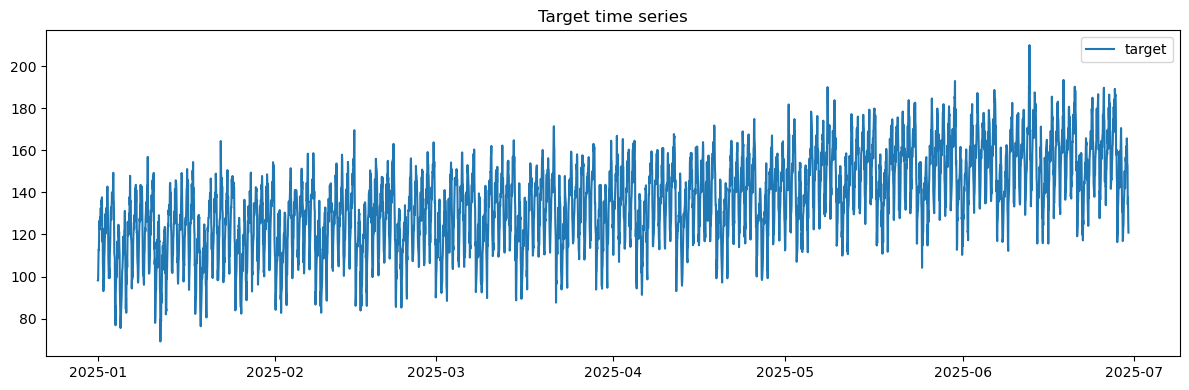

In [4]:
root = Path('/Users/artempetrov/Desktop/AIE/aie_dpo-1/homeworks/HW12')
print('root', root)
dataset_path = root / 'S12-hw-dataset.csv'
df = pd.read_csv(dataset_path)
print('shape', df.shape)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print('min/max', df['date'].min(), df['date'].max())
print('missing', df.isna().sum().to_dict())
if df.isna().values.any():
    df = df.fillna(method='ffill').fillna(method='bfill')
print('after fill missing', df.isna().sum().sum())
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['target'], label='target')
plt.title('Target time series')
plt.legend()
plt.tight_layout()
(root / 'artifacts' / 'figures').mkdir(parents=True, exist_ok=True)
plt.savefig(root / 'artifacts' / 'figures' / 'series_overview.png')
plt.show()


indices train 3024 val 3672 test 4320
sizes 3024 648 648


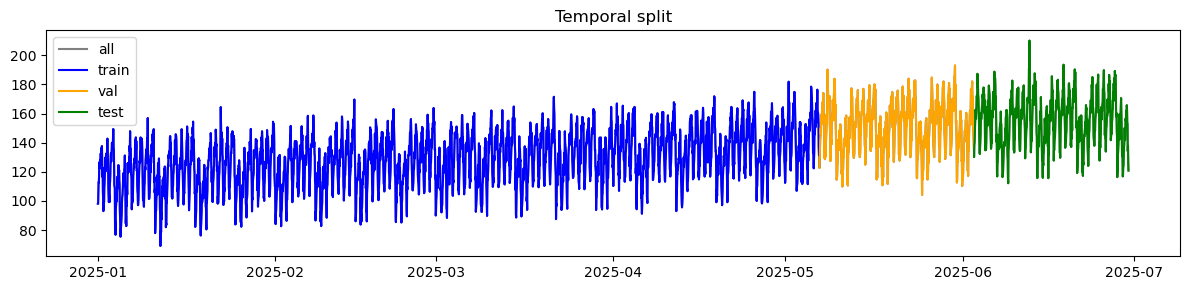

In [5]:
n = len(df)
train_end = int(n * 0.7)
val_end = int(n * 0.85)
print('indices', 'train', train_end, 'val', val_end, 'test', n)
train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()
print('sizes', len(train_df), len(val_df), len(test_df))
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(df['date'], df['target'], label='all', color='gray')
ax.plot(train_df['date'], train_df['target'], label='train', color='blue')
ax.plot(val_df['date'], val_df['target'], label='val', color='orange')
ax.plot(test_df['date'], test_df['target'], label='test', color='green')
ax.legend()
ax.set_title('Temporal split')
plt.tight_layout()
plt.savefig(root / 'artifacts' / 'figures' / 'series_split.png')
plt.show()


In [6]:
def make_features(df):
    x = df.copy()
    x['lag_1'] = x['target'].shift(1)
    x['lag_7'] = x['target'].shift(7)
    x['lag_14'] = x['target'].shift(14)
    x['rolling_mean_7'] = x['target'].shift(1).rolling(7, min_periods=1).mean()
    x['rolling_std_7'] = x['target'].shift(1).rolling(7, min_periods=1).std().fillna(0)
    x['dow'] = x['date'].dt.dayofweek
    x['is_weekend'] = x['dow'].isin([5,6]).astype(float)
    x = x.dropna().reset_index(drop=True)
    return x
train_feat = make_features(train_df)
val_feat = make_features(pd.concat([train_df.iloc[-14:], val_df], ignore_index=True))
test_feat = make_features(pd.concat([val_df.iloc[-14:], test_df], ignore_index=True))
print('after features', train_feat.shape, val_feat.shape, test_feat.shape)


after features (3010, 9) (648, 9) (648, 9)


In [7]:
feature_cols = ['lag_1','lag_7','lag_14','rolling_mean_7','rolling_std_7','dow','is_weekend']
X_train = train_feat[feature_cols].values
y_train = train_feat['target'].values
X_val = val_feat[feature_cols].values
y_val = val_feat['target'].values
X_test = test_feat[feature_cols].values
y_test = test_feat['target'].values
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)
print('scaler fit done')


scaler fit done


B1 val (6.444814814814815, 8.20102295260389, 4.39792166354992) test (6.342438271604938, 8.05906919540317, 4.1485481293996385)
B2 val (12.702012786596118, 15.217644526713752, 8.81686403093607) test (12.740308641975307, 15.238698825884763, 8.549006329583134)
B3 val (7.848810633399735, 9.337104871712146, 5.228092768487707) test (8.286156567529597, 9.990780747182873, 5.309379342957003)


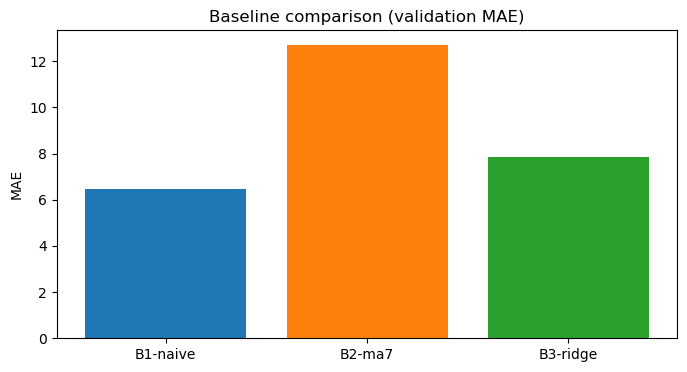

In [16]:
def mae_rmse_mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-6))) * 100
    return mae, rmse, mape

# B1 naive last value
y_val_pred = val_feat['lag_1'].values
b1_val = mae_rmse_mape(y_val, y_val_pred)
y_test_pred = test_feat['lag_1'].values
b1_test = mae_rmse_mape(y_test, y_test_pred)

# B2 moving average 7
y_val_pred = val_feat['rolling_mean_7'].values
b2_val = mae_rmse_mape(y_val, y_val_pred)
y_test_pred = test_feat['rolling_mean_7'].values
b2_test = mae_rmse_mape(y_test, y_test_pred)

# B3 ridge
ridge = Ridge(alpha=1.0, random_state=SEED)
ridge.fit(X_train_s, y_train)
y_val_pred = ridge.predict(X_val_s)
b3_val = mae_rmse_mape(y_val, y_val_pred)
y_test_pred = ridge.predict(X_test_s)
b3_test = mae_rmse_mape(y_test, y_test_pred)

print('B1 val', b1_val, 'test', b1_test)
print('B2 val', b2_val, 'test', b2_test)
print('B3 val', b3_val, 'test', b3_test)

# Baseline comparison plot (val MAE)
models = ['B1-naive', 'B2-ma7', 'B3-ridge']
val_mae = [b1_val[0], b2_val[0], b3_val[0]]
val_rmse = [b1_val[1], b2_val[1], b3_val[1]]
val_mape = [b1_val[2], b2_val[2], b3_val[2]]

plt.figure(figsize=(8, 4))
plt.bar(models, val_mae, color=['tab:blue', 'tab:orange', 'tab:green'])
plt.title('Baseline comparison (validation MAE)')
plt.ylabel('MAE')
plt.savefig(root / 'artifacts' / 'figures' / 'baselines_compare.png')
plt.show()


In [10]:
class TimeSeriesDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

window_size = 14
def create_windows(series, window_size):
    x, y = [], []
    for i in range(len(series) - window_size):
        x.append(series[i:i+window_size])
        y.append(series[i+window_size])
    return np.array(x), np.array(y)

y_train_series = train_df['target'].values
y_val_series = val_df['target'].values
y_test_series = test_df['target'].values

X_train_seq, y_train_seq = create_windows(y_train_series, window_size)
X_val_seq, y_val_seq = create_windows(np.concatenate([y_train_series[-window_size:], y_val_series]), window_size)
X_test_seq, y_test_seq = create_windows(np.concatenate([y_val_series[-window_size:], y_test_series]), window_size)

scaler_y = StandardScaler()
y_train_seq_s = scaler_y.fit_transform(y_train_seq.reshape(-1, 1)).reshape(-1)
y_val_seq_s = scaler_y.transform(y_val_seq.reshape(-1, 1)).reshape(-1)
y_test_seq_s = scaler_y.transform(y_test_seq.reshape(-1, 1)).reshape(-1)

scaler_x = StandardScaler()
X_train_seq_flat = X_train_seq.reshape(-1, 1)
X_val_seq_flat = X_val_seq.reshape(-1, 1)
X_test_seq_flat = X_test_seq.reshape(-1, 1)

scaler_x.fit(X_train_seq_flat)
X_train_seq_s = scaler_x.transform(X_train_seq_flat).reshape(-1, window_size, 1)
X_val_seq_s = scaler_x.transform(X_val_seq_flat).reshape(-1, window_size, 1)
X_test_seq_s = scaler_x.transform(X_test_seq_flat).reshape(-1, window_size, 1)

train_dataset_seq = TimeSeriesDataset(X_train_seq_s, y_train_seq_s)
val_dataset_seq = TimeSeriesDataset(X_val_seq_s, y_val_seq_s)
test_dataset_seq = TimeSeriesDataset(X_test_seq_s, y_test_seq_s)

train_loader = DataLoader(train_dataset_seq, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset_seq, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset_seq, batch_size=32, shuffle=False)


In [12]:
class GRUNet(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

def train_model(model, train_loader, val_loader, epochs=50, lr=0.001):
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    best_val = float('inf')
    best_state = None
    history = {'train_loss': [], 'val_loss': []}
    for ep in range(epochs):
        model.train()
        train_loss = 0
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            opt.zero_grad()
            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            opt.step()
            train_loss += loss.item() * x_batch.size(0)
        train_loss /= len(train_loader.dataset)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device); y_batch = y_batch.to(device)
                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item() * x_batch.size(0)
        val_loss /= len(val_loader.dataset)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_state = model.state_dict()
        if ep % 10 == 0:
            print(f'epoch {ep} train_loss {train_loss:.4f} val_loss {val_loss:.4f}')
    model.load_state_dict(best_state)
    return model, history

model = GRUNet()
model = model.to(device)
best_model, history = train_model(model, train_loader, val_loader, epochs=60, lr=0.001)


epoch 0 train_loss 0.5233 val_loss 0.4327
epoch 10 train_loss 0.1255 val_loss 0.2169
epoch 20 train_loss 0.1127 val_loss 0.1916
epoch 30 train_loss 0.1092 val_loss 0.1859
epoch 40 train_loss 0.1073 val_loss 0.1805
epoch 50 train_loss 0.1060 val_loss 0.1836


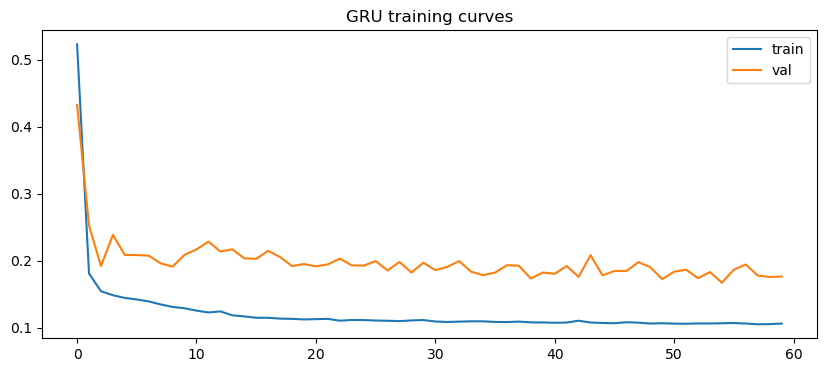

R1 val (6.078896296936788, 7.770593727639245, 4.083312628206827) test (7.207250543759194, 8.972142475266025, 4.646455343869104)


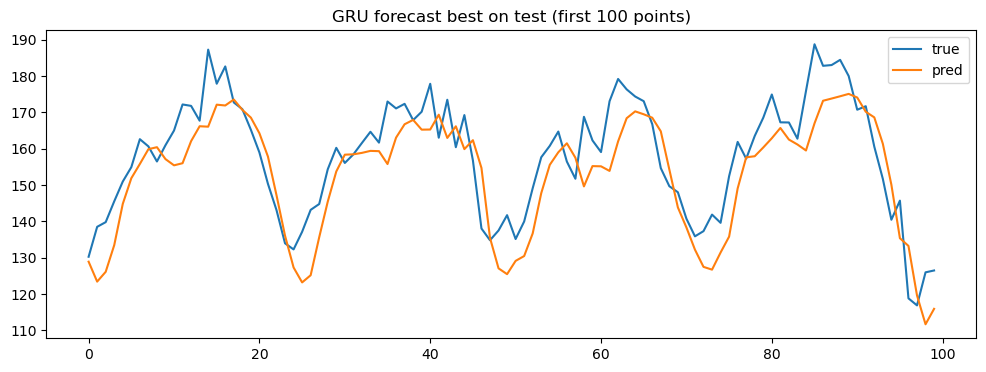

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.legend()
plt.title('GRU training curves')
plt.savefig(root / 'artifacts' / 'figures' / 'gru_learning_curves.png')
plt.show()

def predict_dataset(model, loader):
    model.eval()
    out = []
    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(device)
            y_hat = model(x_batch).cpu().numpy().reshape(-1)
            out.append(y_hat)
    return np.concatenate(out)

y_val_pred_s = predict_dataset(best_model, val_loader)
y_test_pred_s = predict_dataset(best_model, test_loader)
y_val_pred = scaler_y.inverse_transform(y_val_pred_s.reshape(-1,1)).reshape(-1)
y_test_pred = scaler_y.inverse_transform(y_test_pred_s.reshape(-1,1)).reshape(-1)

r1_val = mae_rmse_mape(y_val_seq, y_val_pred)
r1_test = mae_rmse_mape(y_test_seq, y_test_pred)
print('R1 val', r1_val, 'test', r1_test)

# plot best forecast on test
plt.figure(figsize=(12, 4))
plt.plot(y_test_seq[:100], label='true')
plt.plot(y_test_pred[:100], label='pred')
plt.title('GRU forecast best on test (first 100 points)')
plt.legend()
plt.savefig(root / 'artifacts' / 'figures' / 'best_forecast_test.png')
plt.show()


In [14]:
root_artifacts = root / 'artifacts'
root_artifacts.mkdir(parents=True, exist_ok=True)
(root_artifacts / 'figures').mkdir(exist_ok=True)

# save runs.csv
runs = [
    {'experiment_id': 'B1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED, 'split_summary':'70/15/15', 'window_size': '', 'horizon': 1, 'model_summary':'naive-last', 'features_summary':'last value','scaler':'None','optimizer':'None','lr':'None','epochs_trained':'0','best_val_mae':b1_val[0],'best_val_rmse':b1_val[1],'best_val_mape':b1_val[2],'test_mae':b1_test[0],'test_rmse':b1_test[1],'test_mape':b1_test[2],'notes':'naive last'},
    {'experiment_id': 'B2', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED, 'split_summary':'70/15/15', 'window_size': '', 'horizon': 1, 'model_summary':'moving-average', 'features_summary':'rolling mean 7','scaler':'None','optimizer':'None','lr':'None','epochs_trained':'0','best_val_mae':b2_val[0],'best_val_rmse':b2_val[1],'best_val_mape':b2_val[2],'test_mae':b2_test[0],'test_rmse':b2_test[1],'test_mape':b2_test[2],'notes':'ma 7'},
    {'experiment_id': 'B3', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED, 'split_summary':'70/15/15', 'window_size': '', 'horizon': 1, 'model_summary':'ridge-lag-features', 'features_summary':','.join(feature_cols),'scaler':'StandardScaler','optimizer':'None','lr':'None','epochs_trained':'0','best_val_mae':b3_val[0],'best_val_rmse':b3_val[1],'best_val_mape':b3_val[2],'test_mae':b3_test[0],'test_rmse':b3_test[1],'test_mape':b3_test[2],'notes':'Ridge'},
    {'experiment_id': 'R1', 'task': 'forecasting', 'dataset': 'S12-hw-dataset', 'seed': SEED, 'split_summary':'70/15/15', 'window_size': window_size, 'horizon': 1, 'model_summary':'GRU', 'features_summary':'seq of target', 'scaler':'StandardScaler', 'optimizer':'Adam', 'lr':0.001, 'epochs_trained': len(history['train_loss']), 'best_val_mae': r1_val[0], 'best_val_rmse': r1_val[1], 'best_val_mape': r1_val[2], 'test_mae': r1_test[0], 'test_rmse': r1_test[1], 'test_mape': r1_test[2], 'notes':'GRU on sequence'}
]
pd.DataFrame(runs).to_csv(root_artifacts / 'runs.csv', index=False)

torch.save(best_model.state_dict(), root_artifacts / 'best_gru.pt')
with open(root_artifacts / 'best_gru_config.json', 'w') as f:
    json.dump({'model': 'GRU', 'input_size':1, 'hidden_size':32, 'num_layers':1, 'window_size': window_size, 'lr':0.001, 'batch_size':32, 'seed':SEED}, f, indent=4)

print('Artifacts done')


Artifacts done


## Summary
- Cытиуация: модели обучены, сохранены графики, сохранен runs.csv и best_gru.pt
- Следующий шаг: заполнить report.md по шаблону S12-hw-report-template.md
